### A simple trading strategy

We will implement a simple trading strategy: longing an asset depending on how its moving averages behave on short and long time horizons.

In [2]:
%pip install numpy pandas matplotlib yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


Now, we gather the stock data for any asset we want. 

In [63]:
ticker_name = 'GOOGL'    # replace with whatever ticker you like
data = yf.download(ticker_name, start='2000-01-01', end='2025-12-31')   # adjust dates if needed
data.index = pd.to_datetime(data.index)     # ensures that the index is in datetime format
data.columns = data.columns.droplevel('Ticker')     # removes the 'Ticker' level from the column MultiIndex, leaving only the data columns (Open, High, Low, Close, Adj Close, Volume)


[*********************100%***********************]  1 of 1 completed


Next, we calculate rolling averages across two time intervals.

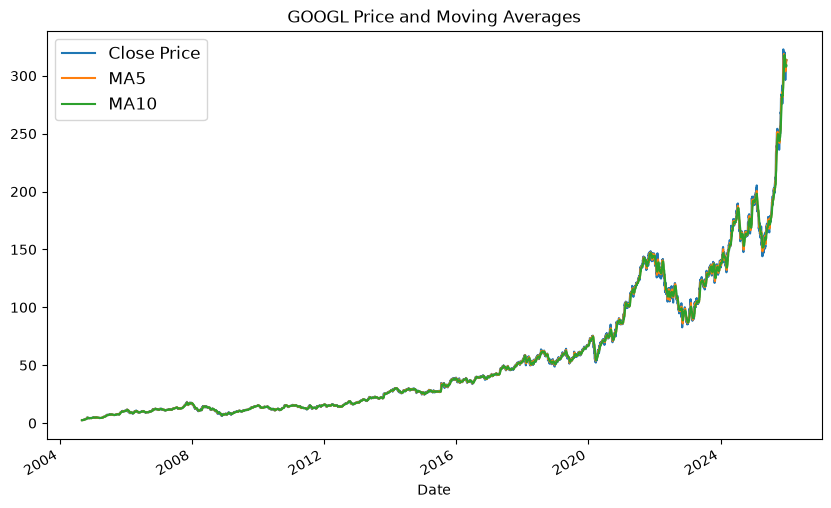

In [64]:
short_window = 5
long_window = 10
data['MA_short'] = data['Close'].rolling(window=short_window).mean()
data['MA_long'] = data['Close'].rolling(window=long_window).mean()
data = data.dropna()  # drop rows with NaN values due to the rolling mean calculations

data['Close'].plot(figsize=(10, 6), label='Close Price')
data['MA_short'].plot(label=f'MA{short_window}')
data['MA_long'].plot(label=f'MA{long_window}')
plt.title(f"{ticker_name} Price and Moving Averages")
plt.legend(fontsize=12)

We now add a new column "Shares". If MA_short > MA_long, this column will take the value 1 (long one share of stock); otherwise, denote as 0 (sell the share). So, we either hold 1 share (when we believe the asset will rise) or 0 shares (when we believe the asset will fall).


In [65]:
data['Shares'] = np.where(data['MA_short'] > data['MA_long'],1,0)

We wish to track the profit (raw, not percentage) on a daily basis. So we shift the closing price by 1 day, and then subtract.

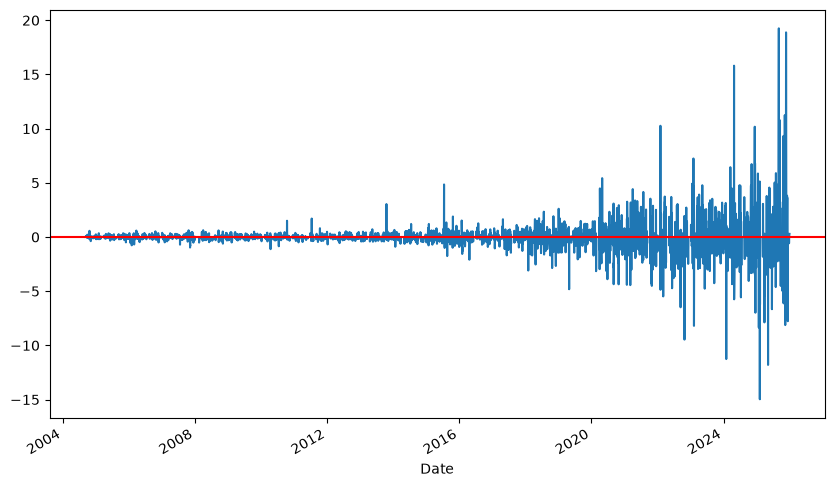

In [67]:
data['Profit'] = (data['Close'].shift(-1) - data['Close'])*data['Shares']
data['Profit'].plot(figsize = (10,6))
plt.axhline(y=0, color='red')

Adding up the profits cumulatively yields the total wealth accumulated over time.

Text(0.5, 1.0, 'Cumulative earnings by trading GOOGL = $137.52')

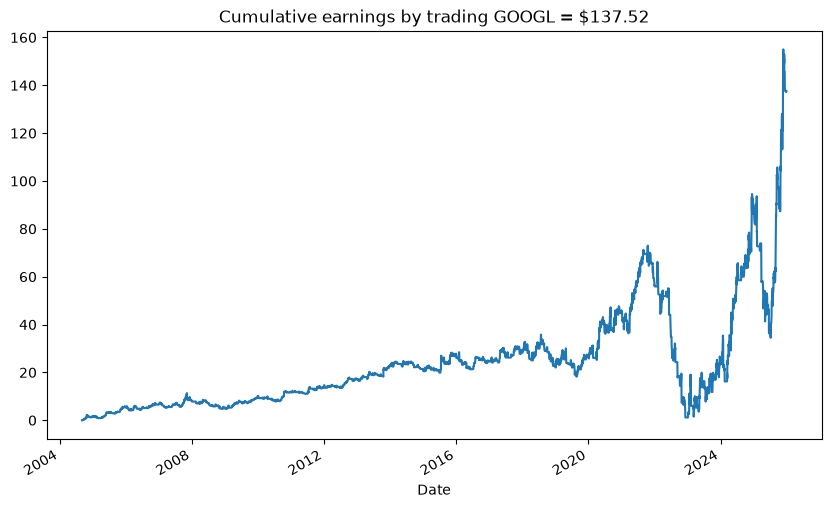

In [68]:
data['Earnings'] = data['Profit'].cumsum()
data['Earnings'].plot(figsize = (10,6))
plt.title(f"Cumulative earnings by trading {ticker_name} = ${data['Earnings'].iloc[-2]:.2f}")

We can also level-set these cumulative earnings by considering how much it cost us to buy the very first share in this strategy. To do so, we must identify _when_ this first purchase was made.

In [69]:
data['signal_change'] = data['Shares'].diff()
first_buy_row = data[data['signal_change'] == 1].head(1)
first_buy_date = first_buy_row.index[0].strftime('%Y-%m-%d') if not first_buy_row.empty else None

try:
    entry_price = data['Close'].loc[first_buy_date]
except IndexError:
    # if MA10 never crossed above MA50 in your dataset
    entry_price = None
    print("The strategy never generated a buy signal in this dataset.")

if entry_price:
    terminal_earnings = data['Earnings'].iloc[-2]
    true_roi = (terminal_earnings / entry_price) * 100
    
    print(f"--- Strategy Performance ---")
    print(f"First Buy Date:    {first_buy_date}")
    print(f"True Entry Price:    ${entry_price:.2f}")
    print(f"Terminal Earnings:    ${terminal_earnings:.2f}")
    print(f"True Strategy ROI:    {true_roi:.2f}%")

--- Strategy Performance ---
First Buy Date:    2004-09-13
True Entry Price:    $2.67
Terminal Earnings:    $137.52
True Strategy ROI:    5157.12%
